<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/key_authors_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

Note: google drive is no longer supported. Adjust the input and output path if needed.

In [ ]:
from __future__ import annotations

# File System
from pathlib import Path

# ML
import pandas as pd
import numpy as np
from pandas.api.types import is_numeric_dtype

# Plot
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import seaborn as sns

# TF-IDf
from sklearn.feature_extraction.text import TfidfVectorizer

# Graphs
import networkx as nx
import matplotlib.patches as mpatches

# sklearn
from sklearn.feature_selection import mutual_info_classif

# General
import math
from collections.abc import Iterable
from tqdm import tqdm
import re

# Loading and Exporting

## Parameters

In [2]:
# dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
# file_name = "Ecuador_part_3.gzip.parquet"  # file name
# dataset_procced_date = "2026_01_08"        # ("%Y_%m_%d")


dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
file_name = "Ecuador_part_all.gzip.parquet"  # file name
dataset_procced_date = "2026_01_10"        # ("%Y_%m_%d")

# Recommended: working directory is: "Backbone-Graph/src"



account_id_col = "accountid"
top_n = 300 # number of top authors to consider as key authors for each narattive topic
topic_col = "BERTopic_topic_512"


## Load Data

In [3]:
# Note: Google Colab not supported anymore.

# Cluster\Local
# Recommended: working directory is: "Backbone-Graph/src"
file_name_no_suffixes = file_name.split(".")[0]
processed_dataset_path = Path("../experimental_results") / dataset_folder / file_name_no_suffixes / dataset_procced_date
# Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"
df_input_path = processed_dataset_path / f"processed_{file_name}"
print(f"Running on local/cluster.\nLoading data from: {df_input_path}")

# Load the parquet file
df = pd.read_parquet(df_input_path)

# for testing
# df = df.sample(n = 50).reset_index(drop=True)

Running on local/cluster.
Loading data from: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/processed_Ecuador_part_all.gzip.parquet


## Output

In [4]:
folder_output_path = processed_dataset_path # save in the save folder as the processed dataset

# Dataset Collums

In [ ]:
print(f"df shpe: {df.shape}")
print("")
print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

df shpe: (1468565, 37)

**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic_512             | int64
BERTopic_prob_512              | float32
BERTopic_to

# Topics Distribution

In [6]:
def extract_number(col_name: str) -> int:
    """Extract first integer found in column name.
    
    Args:
        col_name: Column name string.
        
    Returns:
        int: Extracted number or -1 if none found.
    """
    match = re.search(r"\d+", col_name)
    return int(match.group()) if match else -1

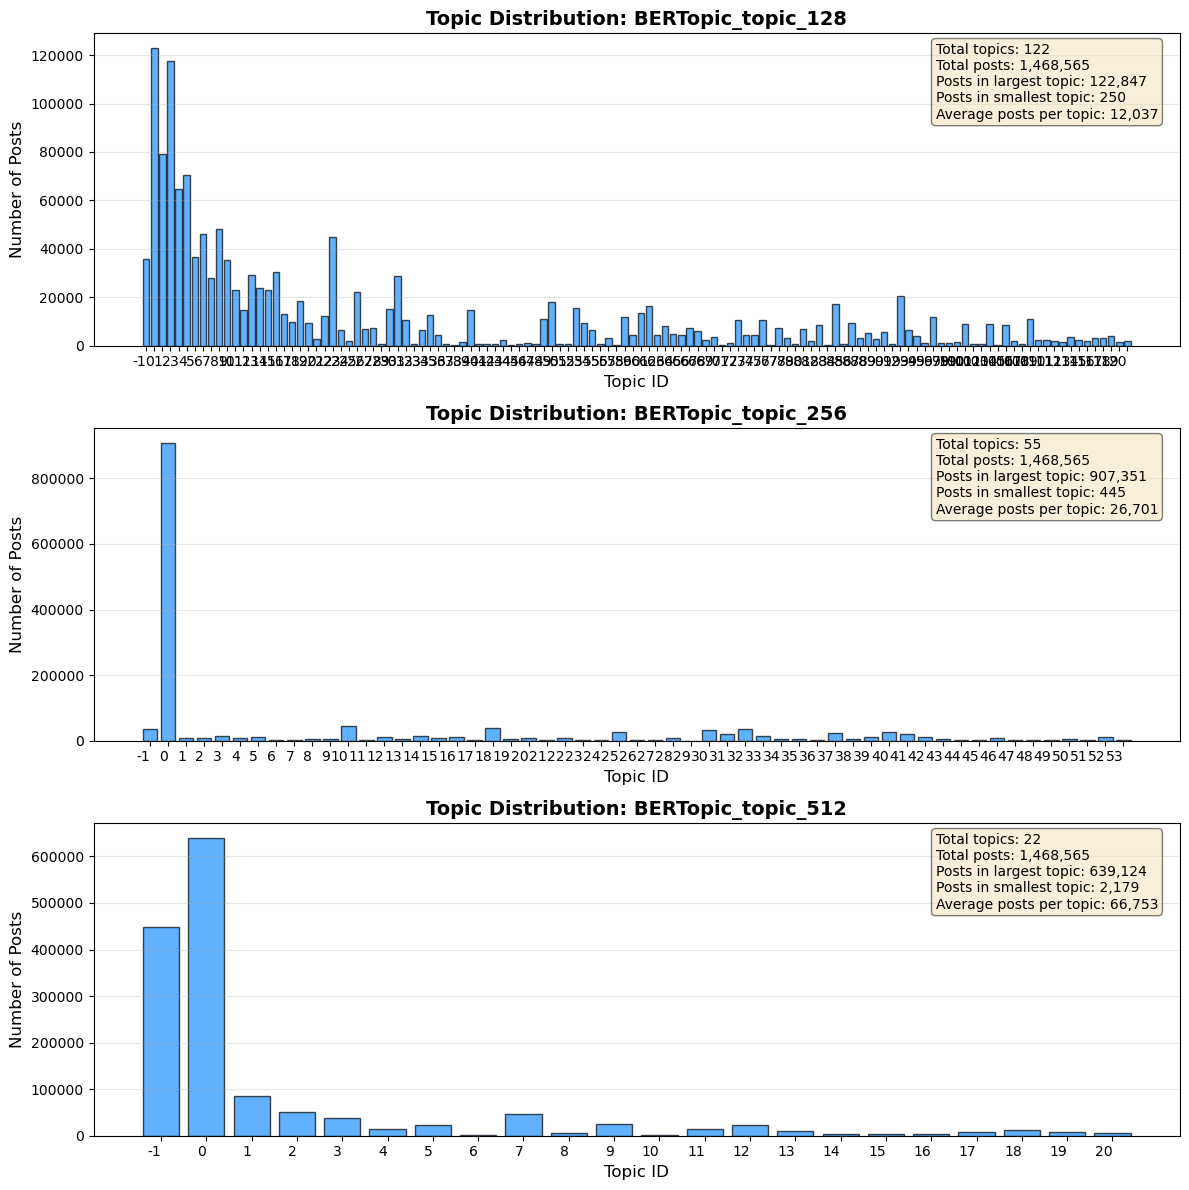

In [7]:
# Find all columns with "BERT", "K_Means", or "topic" in the name (excluding "prob" columns)
topic_columns = [
    col for col in df.columns 
    if any(keyword.lower() in col.lower() for keyword in ["BERT", "K_Means", "topic"])
    and "prob" not in col.lower()
]
topic_columns = sorted(topic_columns, key=extract_number)

# Create distribution plots for each topic column
num_cols = len(topic_columns)
fig, axes = plt.subplots(num_cols, 1, figsize=(12, 4 * num_cols))

# Handle case where there's only one column (axes won't be an array)
if num_cols == 1:
    axes = [axes]

for idx, col in enumerate(topic_columns):
    # Count posts per topic
    topic_counts = df[col].value_counts().sort_index()
    
    # Create bar plot
    axes[idx].bar(topic_counts.index, topic_counts.values, color='dodgerblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"Topic Distribution: {col}", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Topic ID", fontsize=12)
    axes[idx].set_ylabel("Number of Posts", fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Set x-ticks to show all topic IDs
    axes[idx].set_xticks(topic_counts.index)
    axes[idx].set_xticklabels(topic_counts.index, rotation=0, ha='right')
    
    # Add count information
    topic_counts = df[col].value_counts()
    axes[idx].text(
        0.98, 0.97,
        f"Total topics: {len(topic_counts)}\n"
        f"Total posts: {len(df):,}\n"
        f"Posts in largest topic: {topic_counts.max():,}\n"
        f"Posts in smallest topic: {topic_counts.min():,}\n"
        f"Average posts per topic: {topic_counts.mean():,.0f}",
        transform=axes[idx].transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        multialignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()

plt.savefig(folder_output_path / f"topic_distributions.png", dpi=300)
plt.show()
plt.close()



# TF-IDF Score

In [8]:
# prams
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]

## Entities

TF-IDF Using *sklearn*

In [9]:
def compute_entities_tfidf(df, entity_col, topic_col="BERTopic_topic"):
    """
    Compute TF-IDF over entities grouped by topic.
    Output shape: rows = entities, columns = topics.

    Args:
        df (pd.DataFrame): Contains [topic_col] and [entity_col] (list of entities).
        entity_col (str): Column with lists of entities per post.
        topic_col (str): Topic label column.

    Returns:
        pd.DataFrame: TF-IDF matrix (rows = entities, columns = topics).
    """

    print(f"Using topic column: {topic_col}")

    # 1) Explode rows → (topic, entity)
    df_exp = (
        df[[topic_col, entity_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .astype({entity_col: str})
    )

    # 2) Build topic "documents"
    topic_docs_df = (
        df_exp.groupby(topic_col)[entity_col]
              .apply(lambda x: " ".join(x))
              .reset_index()
              .rename(columns={entity_col: "doc"})
    )

    # 3) TF-IDF where rows=topics, cols=entities
    vec = TfidfVectorizer(token_pattern=r"\S+")
    X = vec.fit_transform(topic_docs_df["doc"])

    topic_entity_df = pd.DataFrame(
        X.toarray(),
        index=topic_docs_df[topic_col].values,
        columns=vec.get_feature_names_out()
    )

    # 4) Transpose → rows=entities, columns=topics
    entity_topic_df = topic_entity_df.T

    return entity_topic_df

In [10]:
hashtags_tfidf_df = compute_entities_tfidf(df, entity_col='hashtags', topic_col=topic_col)
hashtags_tfidf_df.head()

Using topic column: BERTopic_topic_512


,-1,0,1,2,3,4,5,6,7,8,...,11,12,13,14,15,16,17,18,19,20
#26s,0.0,0.000358,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#auxilioo,0.0,0.000000,0.0,0.0,0.0,0.0,0.000182,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#bestupid,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#boomshakalaka,0.0,0.000179,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#buenoasi,0.0,0.000179,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
def get_top_entities(entity_topic_df, topic_id, top_n=10):
    """
    Return a list of the top-N entities for a specific topic.

    Args:
        entity_topic_df (pd.DataFrame):
            Rows = entities, columns = topics ids.
        topic_is (str | int):
            The topic.
        top_n (int):
            Number of top entities.

    Returns:
        list[str]: Top-N entities sorted by descending TF-IDF.
    """

    top_entities = entity_topic_df[topic_id].sort_values(ascending=False).head(top_n).index.tolist()

    return top_entities

In [12]:
top_entities = get_top_entities(hashtags_tfidf_df, topic_id = 2, top_n=10)
print(top_entities)

['nuevafotodeperfil', 'rt', 'naughty', 'nsfw', 'tuitutil', 'porn', 'babes', 'sex', 'livecams', 'her']


## Posts

TF-IDF<sub>topic,post</sub> = ∑<sub>entity ∈ post</sub> TF-IDF<sub>topic,entity</sub>

In [13]:
# def compute_post_tfidf(
#     df: pd.DataFrame,
#     topic_col: str,
#     entity_cols_lst: list[str],
#     post_score_col: str = "post_tfidf",
# ) -> None:
#     """Compute per-post TF-IDF scores from multiple entity columns.

#     Updates df[post_score_col].
#     The TF-IDF score of a posts is the score of its entities in its topic, across all entity columns.

#     Args:
#         df: Input DataFrame (modified in place).
#         topic_col: Column containing topic identifiers.
#         entity_cols_lst: List of entity-list columns (each cell is list-like or None).
#         post_score_col: Output column name.

#     Returns:
#         None.
#     """

#     print(f"Using topic column: {topic_col}")
#     print(f"Using entity columns: {entity_cols_lst}")

#     df[post_score_col] = 0.0

#     for entity_col in entity_cols_lst:
#         # rows=entities, columns=topics
#         entities_tfidf_df = compute_entities_tfidf(df, entity_col, topic_col)

#         # Build a fast lookup: (entity, topic) -> tfidf
#         tfidf_dict = entities_tfidf_df.stack().to_dict()

#         for row in tqdm(df.itertuples(index=True), total=len(df), desc=f"Add tf-idf scores of {entity_col}"):
#             idx = row.Index
#             topic = getattr(row, topic_col)
#             ents = getattr(row, entity_col)

#             if ents.size == 0: # no entities
#                 score = 0.0
#             else:
#                 score = float(sum(tfidf_dict.get((e, topic), 0.0) for e in ents))

#             df.at[idx, post_score_col] += score

In [14]:
def compute_post_tfidf(
    df: pd.DataFrame,
    topic_col: str,
    entity_cols_lst: list[str],
    post_score_col: str = "post_tfidf",
) -> None:
    """Compute per-post TF-IDF scores from multiple entity columns.

    Updates df[post_score_col] in place.

    Args:
        df: Input DataFrame.
        topic_col: Topic column name.
        entity_cols_lst: Entity-list column names.
        post_score_col: Output score column name.

    Returns:
        None.
    """
    print(f"Using topic column: {topic_col}")
    print(f"Using entity columns: {entity_cols_lst}\n")

    total_scores = np.zeros(len(df), dtype=float)
    topics = df[topic_col].to_numpy()

    for entity_col in entity_cols_lst:
        # Making entities lookup
        entities_tfidf_df = compute_entities_tfidf(df, entity_col, topic_col)
        tfidf_dict = entities_tfidf_df.stack().to_dict()

        # temp scores for this column
        col_scores = np.zeros(len(df), dtype=float)

        # Entities as numpy array for faster access. [[e1, e2], [e3], [], ...]
        ents_arrs = df[entity_col].to_numpy()

        for i, (topic, ents) in enumerate(
            tqdm(
                zip(topics, ents_arrs),
                total=len(df),
                desc=f"Add tf-idf scores of {entity_col}",
            )
        ):
            if len(ents) == 0:
                continue
            col_scores[i] = sum(tfidf_dict.get((e, topic), 0.0) for e in ents)

        total_scores += col_scores

    df[post_score_col] = total_scores

In [15]:
compute_post_tfidf(df, topic_col, entity_cols_lst)
df[["post_text", "post_tfidf", topic_col]].head()

Using topic column: BERTopic_topic_512
Using entity columns: ['hashtags', 'account_mentions', 'urls', 'ner_entities']

Using topic column: BERTopic_topic_512


Add tf-idf scores of hashtags: 100%|██████████| 1468565/1468565 [00:02<00:00, 628407.55it/s]


Using topic column: BERTopic_topic_512


Add tf-idf scores of account_mentions: 100%|██████████| 1468565/1468565 [00:06<00:00, 225720.83it/s]


Using topic column: BERTopic_topic_512


Add tf-idf scores of urls: 100%|██████████| 1468565/1468565 [00:02<00:00, 554572.66it/s]


Using topic column: BERTopic_topic_512


Add tf-idf scores of ner_entities: 100%|██████████| 1468565/1468565 [00:02<00:00, 627613.96it/s]


,post_text,post_tfidf,BERTopic_topic_512
0,Vamos a cambiar la forma de hacer comunicación...,0.000000,-1
1,"Damos servicio de manejo de prensa, elaboració...",0.000000,-1
2,@db7c47cef2aa2ba68b5c010d761a03fc1c0f0d1302 Bu...,0.002015,0
3,"Mario, debemos denuciar que en los poderes pub...",0.010293,-1
4,Tambien debemos estar claro que la oposición e...,0.000000,-1


## Authors

*(a = author, t= topic, p = post)*

TF<sub>a, t</sub> = ∑ <sub> p ∈ authors's posts in topic</sub> tfidf_score<sub>p, t</sub>

IDF<sub>a</sub> = log((|all_topics| + offset) / (|author's_topics| + offset))

TF-IDF<sub>a,t</sub> = TF<sub>a, t</sub> * IDF<sub>a</sub>

In [16]:
def compute_author_key_score(
    df: pd.DataFrame,
    topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    post_score_col: str = "post_tfidf",
    author_score_col: str = "topic_author_key_score",
    use_log_idf: bool = True,
    idf_offset: float = 1.0,
    folder_output_path: Path = None,
) -> pd.DataFrame:
    """Compute author–topic TF-IDF and write each post's score to df.

    TF = sum of post scores per (author, topic).
    IDF = penalizes authors active in many topics.
    Output column contains TF-IDF(author, topic) for each post.

    Args:
        df: Input DataFrame with posts.
        topic_col: Topic column name.
        author_col: Author column name.
        post_score_col: Per-post score column.
        author_score_col: Column to store the computed author-topic scores.
        use_log_idf: Apply log to IDF.
        idf_offset: Smoothing constant.
        folder_output_path: If given, save the author-topic TF-IDF matrix to this path.

    Returns:
        author_topic_key_score_df (rows = authors, columns = topics, values = author-topic score)

    """

    print(f"Using topic column: {topic_col}")
    print(f"Using author column: {author_col}")
    print(f"Using post score column: {post_score_col}")
    print(f"Using author score column: {author_score_col}")
    
    # TF matrix: rows = authors, columns = topics, values = tf score
    author_topic_tf = (
        df.groupby([author_col, topic_col])[post_score_col]
        .sum()
        .unstack(fill_value=0)
    )

    # IDF per author
    n_topics = author_topic_tf.shape[1]
    topics_per_author = (author_topic_tf > 0).sum(axis=1)
    idf = (n_topics + idf_offset) / (topics_per_author + idf_offset)
    if use_log_idf:
        idf = np.log(idf)

    # TF-IDF matrix
    author_topic_key_score_df = author_topic_tf.mul(idf, axis=0)

    # Assign TF-IDF(author, topic) to each post
    df[author_score_col] = df.apply(
        # Pandas aligns by row index = author.
        lambda row: author_topic_key_score_df.loc[row[author_col], row[topic_col]],
        axis=1,
    )

    # save
    if folder_output_path is not None:
        author_topic_key_score_df.to_parquet(folder_output_path / f"author_topic_key_score_by_{topic_col}.parquet", compression="gzip")
        print(f"Saved author-topic key score matrix to: {folder_output_path / f'author_topic_key_score_by_{topic_col}.parquet'}")

    return author_topic_key_score_df

In [17]:
author_topic_key_score_df = compute_author_key_score(df, topic_col = topic_col, folder_output_path=folder_output_path)
author_topic_key_score_df.head()

Using topic column: BERTopic_topic_512
Using author column: accountid
Using post score column: post_tfidf
Using author score column: topic_author_key_score
Saved author-topic key score matrix to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/author_topic_key_score_by_BERTopic_topic_512.parquet


BERTopic_topic_512,-1,0,1,2,3,4,5,6,7,8,...,11,12,13,14,15,16,17,18,19,20
accountid,,,,,,,,,,,,,,,,,,,,,
0002e64fc6035627e87f8312ee9c8c0098b1d6cd2a,0.002329,0.018906,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
0005c5f571ae94a562ab590fbcab9138cee6d20507,0.000132,0.001631,0.000000,0.001578,0.003977,0.000000,0.003315,0.0,0.000378,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
0007a45e37da6ae559d6b4b76218874d6ab677234b,0.064927,0.218051,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
000fca065490ad68fbb646d9491061b2abd861703f,0.000000,0.007060,0.000000,0.000000,0.001605,0.000000,0.039710,0.0,0.004970,0.000000,...,0.005754,0.0,0.0,0.0,0.0,0.0,0.0,0.05621,0.0,0.0
0011cb6aa969ab7bc4359a6c445287ca0671aac4c0,0.014280,0.851503,0.023423,0.000000,0.000000,0.010573,0.000000,0.0,0.000000,0.036769,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0


# Key Authors

In [18]:
def get_topic_top_authors(
    df: pd.DataFrame,
    topic: str | int,
    score_col: str = "topic_author_key_score",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 100,
) -> set:
    """Return the top-n authors for a given topic based on author-topic scores.

    The author-topic score is assumed to be precomputed. Each author is
    considered once per topic; repeated posts do not increase the score.

    Args:
        df: DataFrame containing posts with author-topic scores.
        topic: Topic to extract top authors for.
        score_col: Column storing author-topic scores.
        author_col: Column storing author identifiers.
        topic_col: Column storing topic labels.
        n: Number of top authors to return.

    Returns:
        set: Authors ranked in the top-n for the given topic.
    """

    print(f"Using topic column: {topic_col}")

    top_authors = (
        df.loc[df[topic_col] == topic, [author_col, score_col]]
        .dropna(subset=[author_col, score_col])
        .drop_duplicates(author_col)     # one row per author
        .sort_values(score_col, ascending=False)
        .head(n)[author_col]
    )

    topic_key_authors = set(top_authors)

    print(f"There are {len(topic_key_authors)} unique key authors in topic {topic}.")

    return topic_key_authors

In [19]:
get_topic_top_authors(df, topic=1, topic_col = topic_col)

Using topic column: BERTopic_topic_512
There are 100 unique key authors in topic 1.


{'0080b858dcdf930f1029c57f65491e8df51b3bebc5',
 '01769a6a8c78cbbe38511b30c649e3b9a69acd7287',
 '01b0efdd37579f669eb5435ed1d747feced02e4b53',
 '06ae71cd26b039f685ffa49c64780bd86f18fdff94',
 '076e32ebd660b01a866cc68f2fc6e723ca15050a3c',
 '0a8807d5066f19a69e7b28d0652c13320f3b7063b0',
 '0d3b88567bf65211bb328ab87185c347edd4f29f9a',
 '11147ad7649a0fccc3dea617a5e495894df11926d8',
 '123e97476d70378a4e1b523764a0e85feab6d4d5d4',
 '13512f0d9a07cecb53b90bfc2856495eb6e40a0036',
 '18a85c6353e0f14a67e79c858ac310d2a556fcd76e',
 '1b6af2310644a99d47f9866e046d675a7fc9a8d667',
 '1d6a261276b5eb20a1e13ddb1ece2bc8d3a30bb4c0',
 '1dd2833786a852fd5ec6169bc3ef88664c8a67b82c',
 '1decb332cd4b7c2dfa969ebc3f5e9e604a5a183f59',
 '1ffd546573448d5ac5ba1dbabd85c087663f24f29f',
 '23d9d97d91127cb7b65b973df67d2e88cb2143500d',
 '24aa1d4c2a5ac62f28e623121cb8dea96209871f94',
 '29c56783516c3f07f96b1674fc5ef3f7e779c13b9d',
 '305856c24fb12546f54a2793b1b78efe51160065d8',
 '3245a5f61e47d0f28fc827984055b3a2752185ec08',
 '3261f9af008

In [ ]:
def get_all_topics_key_authors(
    df: pd.DataFrame,
    author_score_col: str = "topic_author_key_score",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    key_authors_mode: str = "per_topic",
    base_number: int = 5,
    top_percentage: float = 0.05,
) -> tuple[pd.DataFrame, set]:
    """Return key authors selected by global or per-topic TF-IDF ranking.

    Both modes return a DataFrame with columns [topic_col, author_col, author_score_col],
    where an author can have multiple rows for different topics.

    Modes:
        - "per_topic": For each topic, select base_number + top_percentage * (authors in topic).
        - "global":    Rank authors by their total TF-IDF sum across all topics,
                       select the top top_percentage fraction, then return their per-topic rows.

    Args:
        df: DataFrame with author-topic TF-IDF scores.
        author_score_col: Column storing TF-IDF(author, topic).
        author_col: Column storing author IDs.
        topic_col: Column storing topic labels.
        key_authors_mode: "per_topic" or "global".
        base_number: initial number authors per topic (per_topic mode only).
        top_percentage: Fraction of authors to select (0-1).

    Returns:
        pd.DataFrame: Key authors with columns [topic_col, author_col, author_score_col].
        set: Unique key-author IDs.
    """
    # Normalize mode string
    mode = key_authors_mode.strip().lower().replace(" ", "_")
    assert mode in ("per_topic", "global"), f"Invalid mode: {key_authors_mode!r}. Use 'per_topic' or 'global'."

    assert top_percentage >= 0, "top_percentage must be >= 0."

    print(f"Using topic column: {topic_col}")
    print(f"Mode: {mode}, Base number: {base_number}, Top percentage: {top_percentage:.2%}")


    # Clean base table: one row per (topic, author) with their score
    base = (
        df[[topic_col, author_col, author_score_col]]
        .dropna(subset=[topic_col, author_col, author_score_col])
        .drop_duplicates([topic_col, author_col])
        .sort_values([topic_col, author_score_col], ascending=[True, False])
        .reset_index(drop=True)
    )

    if mode == "global":

        # Rank authors by total TF-IDF sum across all topics
        author_total_tfidf = base.groupby(author_col)[author_score_col].sum()
        n_select = max(1, int(top_percentage * len(author_total_tfidf)))
        selected_authors = set(author_total_tfidf.nlargest(n_select).index)

        # Keep per-topic rows for selected authors
        result = base[base[author_col].isin(selected_authors)].reset_index(drop=True)

    else:  # per_topic
        # Dynamic threshold per topic: base_number + top_percentage * authors_in_topic
        author_counts = base.groupby(topic_col)[author_col].transform("nunique")
        rank_in_topic = base.groupby(topic_col).cumcount()  # already sorted by score desc
        threshold = base_number + (top_percentage * author_counts).astype(int)
        result = base[rank_in_topic < threshold].reset_index(drop=True)

        selected_authors = set(result[author_col])

    # Print summary
    print("Sample of all topic key authors:")
    print("Note: authors may appear multiple times for different topics.")
    n_sample = min(10, len(result))
    if n_sample > 0:
        display(result.sample(n=n_sample))

    unique_count = result[author_col].nunique()
    print(f"There are {unique_count} unique key authors in all topics.")

    return result, selected_authors

In [21]:
# --- Key-author selection mode ---
# "per_topic": base_number + top_percentage * (authors in topic), per topic.
# "global":    top_percentage of all authors ranked by total TF-IDF.
key_authors_mode = "per_topic"
base_number = 10           # minimum authors per topic  (per_topic mode)
top_percentage = 0.1       # fraction of authors to select (both modes)

all_topics_key_authors_df, all_topics_key_authors_set = get_all_topics_key_authors(
    df=df,
    topic_col=topic_col,
    key_authors_mode=key_authors_mode,
    base_number=base_number,
    top_percentage=top_percentage,
)

Using topic column: BERTopic_topic_512
Sample of all topic key authors:
Note: authors may appear multiple times for different topics.


,BERTopic_topic_512,accountid,topic_author_key_score
9670,18,24f2339cad102415852314d433a11c8ee1820ac467,0.206117
8811,13,fce82ffc33ad841c9262b3bb5893fe153fbb6f82e8,2.768013
9088,17,cb32d3e8aa6f7f860bef46a19e9670213ffc4998ab,1.295898
8468,12,2a24bbd97f60348ae576a7753ce7cc4548030970a7,2.391354
2344,0,db0ef2c5f69c92ee8b7198815cc70bda47778cf078,5.298175
127,-1,23f416954118dec4dc9ef7385608d8f2ad5d6e6c7c,40.257205
6678,7,0d3b88567bf65211bb328ab87185c347edd4f29f9a,2.505171
6283,5,889437a4ebed485de7ff85402e0c807deff0bfd71f,0.258381
6451,7,130b721264aa58ac63ddcc0b161e0bc6de6d65f695,30.434004
7356,9,f1887caf0b5a491bf11486cf370268ac5cf634d285,8.654935


There are 6132 unique key authors in all topics.
Mode: per_topic | rows: 9913


# IO Authors

In [22]:
def get_io_authors_by_ratio(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    folder_output_path: Path = None,
) -> set:
    """Return authors classified as IO based on IO-post ratio.

    Args:
        df: Posts DataFrame.
        author_col: Column with author IDs.
        is_io_control_col: Column where 1=control (non-IO), 0=IO.
        io_threshold: Minimum IO ratio to tag an author as IO.
        min_posts: Minimum number of posts per author.

    Returns:
        set: Author IDs tagged as IO.
    """
    grouped = df.groupby(author_col)[is_io_control_col]

    author_stats = pd.DataFrame({
        "total_posts": grouped.count(),
        "io_ratio": 1 - grouped.mean(),
    })

    io_authors = set(
        author_stats[
            (author_stats["total_posts"] >= min_posts)
            & (author_stats["io_ratio"] >= io_threshold)
        ].index
    )

    print(f"There are {len(io_authors)} io authors.")

    if folder_output_path is not None:
        author_stats.to_csv(folder_output_path / "author_io_stats.csv")

    return io_authors

In [23]:
io_authors_set = get_io_authors_by_ratio(df)

There are 711 io authors.


# Key and IO Authors

## Summary

In [ ]:
def save_and_print_io_key_summary(
    df,
    io_authors_set,
    all_topics_key_authors_set,
    output_path: str | Path,
    author_col: str = "accountid",
):
    """Print and save summary statistics for IO / key authors."""

    both_io_and_key = io_authors_set & all_topics_key_authors_set
    pct_io_also_key = (len(both_io_and_key) / len(io_authors_set) * 100 if len(io_authors_set) > 0 else 0)

    all_authors_set = set(df[author_col].astype(str).drop_duplicates())

    summary_text = (
        "### io_key_summary ###\n"
        "\n"
        f"Number of all authors: {len(all_authors_set):,}\n"
        "\n"
        f"Number of IO authors: {len(io_authors_set):,}\n"
        f"Number of key authors: {len(all_topics_key_authors_set):,}\n"
        "\n"
        f"Number of authors that are both IO and key: {len(both_io_and_key):,}\n"
        f"{pct_io_also_key:.1f}% of IO authors are also key authors\n"
    )

    # print to console
    print(summary_text)

    # save to text file
    output_path = Path(output_path)
    summary_file_path = output_path / "io_key_authors_summary.txt"
    with open(summary_file_path, "w", encoding="utf-8") as f:
        f.write(summary_text)

    print(f"Saved summary to: {summary_file_path}")

    return None

In [25]:
print(f"Using topic column: {topic_col}")
save_and_print_io_key_summary(df = df, io_authors_set = io_authors_set, all_topics_key_authors_set = all_topics_key_authors_set, output_path = folder_output_path)

Using topic column: BERTopic_topic_512
### io_key_summary ###

Number of all authors: 21923

Number of IO authors: 711
Number of key authors: 6132

Number of authors that are both IO and key: 573
80.6% of IO authors are also key authors

Saved summary to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/io_key_authors_summary.txt


## Venn Plot

In [26]:
def plot_venn_3_sets(
    all_authors_set: set,
    all_topics_key_authors_set: set,
    io_authors_set: set,
    title: str = "Venn Diagram",
    set_labels: tuple[str, str, str] = ("All authors", "Key authors", "IO authors"),
    folder_output_path: str | Path = None,
) -> None:
    """Plot a 3-set Venn diagram for author subsets.

    Args:
        all_authors_set: Set of all author IDs in the dataset/graph.
        all_topics_key_authors_set: Set of authors selected as key-authors across topics.
        io_authors_set: Set of IO-labeled authors.
        title: Figure title.
        set_labels: Labels for the three sets (A, B, C) in the diagram.
    """
    # Normalize to strings for consistent overlap
    A = set(map(str, all_authors_set))
    B = set(map(str, all_topics_key_authors_set))
    C = set(map(str, io_authors_set))

    plt.figure(figsize=(7, 6))
    v = venn3(
        subsets=(A, B, C),
        set_labels=set_labels,
        set_colors=(
        "#6081B5",  # All
        "#AA6B0C",  # Key 
        "#9E4950",  # IO
    ),
        alpha=0.8,
    )

    # Format numbers with comma separator
    for subset_id in ('100', '010', '001', '110', '101', '011', '111'):
        label = v.get_label_by_id(subset_id)
        if label is not None:
            value = int(label.get_text())
            label.set_text(f"{value:,}")


    plt.title(title)
    plt.tight_layout()


    # Save figure
    if folder_output_path is not None:
      file_name = title.lower().replace(" ", "_").replace(",", "") + ".png"
      folder_output_path = Path(folder_output_path)
      venn_path = folder_output_path / file_name
      plt.savefig(venn_path, dpi=300)
      print(f"Saved fig to: {venn_path}")

    plt.show()
    plt.close()

Using topic column: BERTopic_topic_512
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/authors_overlap_bertopic_topic_512_top_n_300.png


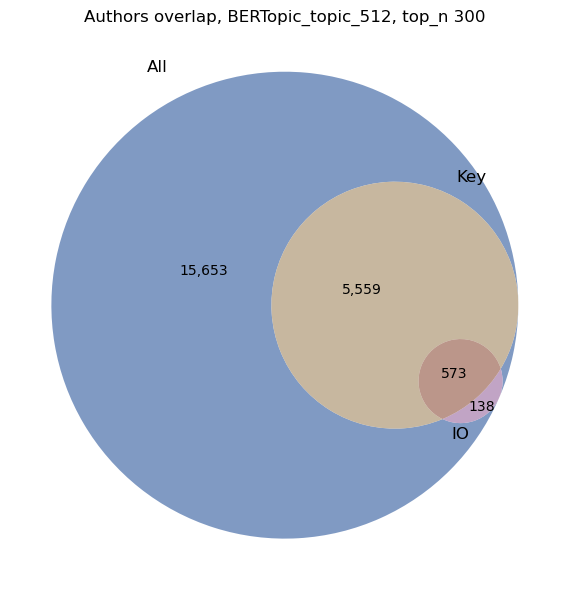

In [27]:
# Compute all authors set
all_authors_set = set(df[account_id_col].astype(str).drop_duplicates())


print(f"Using topic column: {topic_col}")
plot_venn_3_sets(
    all_authors_set=all_authors_set,
    all_topics_key_authors_set=all_topics_key_authors_set,
    io_authors_set=io_authors_set,
    title=f"Authors overlap, {topic_col}, top_n {top_n}",
    set_labels=("All", "Key", "IO"),
    folder_output_path=folder_output_path,
)

# Networkx Graphs

## Parameters

In [28]:
account_relations = [
    # (src_col, dst_col)
    ("in_reply_to_accountid", "accountid"),
    ("account_mentions", "accountid"),
    ("reposted_accountid", "accountid"),

    ("hashtags_reuse_12H_accountids", "accountid"),
    ("urls_reuse_12H_accountids", "accountid"),
    ("account_mentions_reuse_12H_accountids", "accountid"),
    ("ner_entities_reuse_12H_accountids", "accountid"),
    
    ("hashtags_reuse_3D_accountids", "accountid"),
    ("urls_reuse_3D_accountids", "accountid"),
    ("account_mentions_reuse_3D_accountids", "accountid"),
    ("ner_entities_reuse_3D_accountids", "accountid")

    # text similarity, not implemented
]

## Build Account ↔ Account Graph

In [ ]:
def add_relation_edges(
    G: nx.Graph,
    df: pd.DataFrame,
    src_col: str,
    dst_col: str,
    weight: int = 1,
    ignore_self_loops: bool = True,
    all_topics_key_authors_set: set | None = None,
    author_topic_key_score_df: pd.DataFrame | None = None,
    io_authors: set | None = None,
) -> None:
    """Add weighted edges to a graph and annotate author nodes.

    This builds edges from co-occurrence counts of (src, dst) pairs.
    Edge weights are incremented by `weight` for each co-occurrence.
    Annotates nodes with: (optional)
        * io_author: 1 if author in `io_authors`, else 0
        * score: aggregated author-topic score 
        * participan_at_topics: list of topics the author is active in

    Args:
        G: Target NetworkX graph.
        df: DataFrame containing relation columns.
        src_col: Source column name (scalar or list-like).
        dst_col: Destination column name (scalar or list-like).
        weight: Multiplier applied to counted co-occurrences.
        ignore_self_loops: If True, drops rows where src == dst.
        all_topics_key_authors_set: Optional set of key authors.
        author_topic_key_score_df: Optional DataFrame with author-topic scores (index=author, columns=topics). 
            - The author column in df should match src_col and dst_col.
        io_authors: Optional set of IO-labeled authors.

    Returns:
        None
    """

    if all_topics_key_authors_set is None:
        print("all_topics_key_authors_set is None.")
    if io_authors is None:
        print("io_authors is None.")
    if author_topic_key_score_df is None:
        print("author_topic_key_score_df is None.")
    

    # make pairs of src-dst
    pairs = df[[src_col, dst_col]].dropna()
    pairs = pairs.explode(src_col).dropna(subset=[src_col])
    pairs = pairs.explode(dst_col).dropna(subset=[dst_col])
    pairs[src_col] = pairs[src_col].astype(str)
    pairs[dst_col] = pairs[dst_col].astype(str)

    # remove self loops
    if ignore_self_loops:
        pairs = pairs[pairs[src_col] != pairs[dst_col]]

    # filter to key authors
    if all_topics_key_authors_set is not None:
        pairs = pairs[pairs[src_col].isin(all_topics_key_authors_set) & pairs[dst_col].isin(all_topics_key_authors_set)]


    # aggregate counts of (src, dst) pairs → edge weights
    counts = pairs.value_counts([src_col, dst_col]).reset_index(name="count") # columns: [src_col, dst_col, count]

    print("pairs.value_counts head:")
    print(f"Counts df columns: {counts.columns.tolist()}")
    display(counts.head())

    # main loop
    for row in counts.itertuples(index=False):
        src = getattr(row, src_col)
        dst = getattr(row, dst_col)
        w = int(row.count) * weight

        # Add or update edge weight
        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
            continue # skip to next row, dont update labels again

        # add the edge (automatically add nodes if needed)
        G.add_edge(src, dst, weight=w)
            
        # add labels to nodes
        for author in [src, dst]:

            # io label
            if io_authors is not None:
                G.nodes[author]["io_author"] = int(author in io_authors)

            # add author key score labels
            if author_topic_key_score_df is not None:
                # author_topic_key_score_df (rows = authors, columns = topics, values = author-topic score)

                author_topic_scores = author_topic_key_score_df.loc[author] # Series with index=topics, values=author-topic scores

                top_topic = author_topic_scores.idxmax()
                G.nodes[author]["top_topic"] = top_topic # topic with the highest score for this author

                top_topic_score = author_topic_scores[top_topic]
                G.nodes[author]["top_topic_key_score"] = top_topic_score

                top_5_topics = author_topic_scores.nlargest(5).index.tolist()
                G.nodes[author]["top_5_topics"] = ",".join(map(str, top_5_topics))

                score_sum = author_topic_scores.sum()
                G.nodes[author]["all_topics_key_score_sum"] = score_sum

                # Topic Dominance
                # higher dominance means more uneven distribution of scores across topics. 
                key_score_dominance = author_topic_scores.max() / (author_topic_scores.sum() + 1e-6)  # add small constant to avoid div by zero
                G.nodes[author]["key_score_dominance"] = key_score_dominance

                

    return None

In [30]:
def build_accounts_graph(
    df: pd.DataFrame,
    account_relations: list[tuple[str, str]],
    topic_col: str = "BERTopic_topic_512",
    io_authors: set | None = None,
    all_topics_key_authors_set: set | None = None,
    author_topic_key_score_df: pd.DataFrame | None = None,
    is_directed_graphs: bool = True,
    output_path: Path | None = None,
) -> nx.Graph:
    """Build a directed accounts interaction graph and optionally export to GEXF.

    Args:
        df: Posts DataFrame.
        account_relations: List of (src_col, dst_col) relations. Columns must exist in df.
        topic_col: Topic column name (used in add_relation_edges).
        io_authors: Set of IO authors (used to tag nodes).
        all_topics_key_authors_set: Optional set of key authors.
        author_topic_key_score_df: Optional DataFrame with author-topic scores for node labels.
        is_directed_graphs (bool): If True, use a directed graph (nx.DiGraph); otherwise use an undirected graph (nx.Graph).
        authors_score_col: Column name for author-topic scores.
        output_path: If provided, writes `<output_path>/<topic_col>_accounts_graph.gexf`.

    Returns:
        nx.DiGraph: The constructed accounts graph.
    """
    # create graph
    if is_directed_graphs:
        G = nx.DiGraph()
    else:
        G = nx.Graph()

    # Set graph name (exported to GEXF)
    G.graph["name"] = f"{topic_col}_accounts_graph"

    # User Warnings
    if io_authors is None:
        print("Warning: io_authors is None. No nodes will be tagged as io_author.")
    if all_topics_key_authors_set is None:
        print("Warning: all_topics_key_authors_set is None. No filtering will be applied.")
    if author_topic_key_score_df is None:
        print("Warning: author_topic_key_score_df is None. No node score-labels will be included.")

    # Add nodes and edges
    for src_col, dst_col in tqdm(account_relations, desc="Adding account edges"):
        print(f"[build_accounts_graph] Now adding edges of {dst_col}")
        add_relation_edges(
            G,
            df,
            src_col=src_col,
            dst_col=dst_col,
            weight=1,
            ignore_self_loops=True,
            all_topics_key_authors_set=all_topics_key_authors_set,
            author_topic_key_score_df=author_topic_key_score_df,
            io_authors=io_authors,
        )

    # Save
    if output_path is not None:
        graph_output_path = output_path / f"{topic_col}_accounts_graph.gexf"
        nx.write_gexf(G, graph_output_path)
        print(f"Saved graph to: {graph_output_path}")

    return G

In [31]:
G_accounts = build_accounts_graph(
    df=df,
    account_relations = account_relations,
    topic_col=topic_col,
    io_authors=io_authors_set,
    all_topics_key_authors_set = all_topics_key_authors_set,
    author_topic_key_score_df = author_topic_key_score_df,
    is_directed_graphs = True,
    output_path = folder_output_path,
)

Adding account edges:   0%|          | 0/11 [00:00<?, ?it/s]

[build_accounts_graph] Now adding edges of accountid
pairs.value_counts head:
Counts df columns: ['in_reply_to_accountid', 'accountid', 'count']


,in_reply_to_accountid,accountid,count
0,bef0e7981715abed0539a1eb8eedfdbf59651779f2,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,1175
1,bef0e7981715abed0539a1eb8eedfdbf59651779f2,71b45b9cfbe033acf94c15763207cc9f35746ad22a,623
2,bef0e7981715abed0539a1eb8eedfdbf59651779f2,70977662b5d96b2cf7604f9de940a581576abcd991,572
3,bef0e7981715abed0539a1eb8eedfdbf59651779f2,cd0b8e047f5b20eed79cf903fd915afdf4458bc3b4,498
4,bef0e7981715abed0539a1eb8eedfdbf59651779f2,cf9df49a2ed509861be9393631f3b5899196dc8138,296


Adding account edges:   9%|▉         | 1/11 [00:04<00:43,  4.36s/it]

[build_accounts_graph] Now adding edges of accountid
pairs.value_counts head:
Counts df columns: ['account_mentions', 'accountid', 'count']


...

Adding account edges:  91%|█████████ | 10/11 [12:42<01:14, 74.19s/it]

[build_accounts_graph] Now adding edges of accountid
pairs.value_counts head:
Counts df columns: ['ner_entities_reuse_3D_accountids', 'accountid', 'count']


,ner_entities_reuse_3D_accountids,accountid,count
0,cea0b6abc111f3ee47a98af23b1a594373469df377,0d3b88567bf65211bb328ab87185c347edd4f29f9a,2576
1,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,70977662b5d96b2cf7604f9de940a581576abcd991,2410
2,cea0b6abc111f3ee47a98af23b1a594373469df377,ab27c1a26d0d24fdea455ac9d7272fb92cccc1c46f,2408
3,0d3b88567bf65211bb328ab87185c347edd4f29f9a,ab27c1a26d0d24fdea455ac9d7272fb92cccc1c46f,2402
4,70977662b5d96b2cf7604f9de940a581576abcd991,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,2399


Adding account edges: 100%|██████████| 11/11 [15:15<00:00, 83.21s/it]


Saved graph to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/BERTopic_topic_512_accounts_graph.gexf


## Plot Accounts Graph

In [32]:
def plot_accounts_graph(
    G: nx.Graph,
    folder_output_path: str | Path | None = None,
    graph_name: str = "accounts_graph",
    figsize: tuple = (12, 12),
    key_authors: set | Iterable | None = None,
    layout: str = "spring",
):
    """Plot a NetworkX graph and highlight IO authors.
    
    Args:
        G: Input NetworkX graph with node attribute 'io_author' (1 for IO, 0 for non-IO).
        folder_output_path: If provided, saves the plot to this folder.
        graph_name: Base name for the saved plot file.
        figsize: Figure size for the plot.
        key_authors: If provided, only plot the subgraph induced by these authors.
        layout: Layout algorithm from NetworkX. Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
    """
    if key_authors is not None:
        key_authors = set(map(str, key_authors))
        G_plot = G.subgraph(key_authors)
    else:
        G_plot = G

    n_nodes = G_plot.number_of_nodes()
    n_io = sum(1 for n in G_plot.nodes if G_plot.nodes[n].get("io_author", 0) == 1)
    n_legitimate = n_nodes - n_io
    
    print(f"Plotting graph with {n_nodes} nodes: {n_io} IO authors, {n_legitimate} legitimate authors")
    
    plt.figure(figsize=figsize)
    
    # Choose layout
    if layout == "spring":
        pos = nx.spring_layout(G_plot, seed=42)
    elif layout == "circular":
        pos = nx.circular_layout(G_plot)
    elif layout == "random":
        pos = nx.random_layout(G_plot, seed=42)
    elif layout == "shell":
        pos = nx.shell_layout(G_plot)
    elif layout == "spectral":
        pos = nx.spectral_layout(G_plot)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G_plot)
    else:
        raise ValueError(f"Unknown layout: {layout}")

    node_colors = [
        "red" if G_plot.nodes[n].get("io_author", 0) == 1 else "steelblue"
        for n in G_plot.nodes
    ]

    nx.draw(
        G_plot,
        pos,
        node_size=30,
        node_color=node_colors,
        edge_color="gray",
        width=0.5,
        alpha=0.8,
        with_labels=False,
    )

    legend_elements = [
        mpatches.Patch(color="steelblue", label=f"Non-IO author ({n_legitimate} nodes)"),
        mpatches.Patch(color="red", label=f"IO author ({n_io} nodes)"),
    ]
    plt.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=10)

    if folder_output_path is not None:
        plot_path = Path(folder_output_path) / f"{graph_name}_{layout}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph to: {plot_path}")

    plt.show()
    plt.close()


In [33]:
# Layout Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
# plot_accounts_graph(G = G_accounts, folder_output_path = folder_output_path, graph_name = f"{topic_col}_accounts_graph", layout="spring")

# IO Indicators

e.g, centralities, core number

## Compute Indicators


[Facebook Network Analysis](https://networkx.org/nx-guides/content/exploratory_notebooks/facebook_notebook.html) </br>
[NX Algoritms](https://networkx.org/documentation/stable/reference/algorithms/index.html)

In [ ]:
def compute_indicators(G: nx.Graph, output_folder_path: str | Path | None = None) -> pd.DataFrame:
    """Compute multiple graph centralities.

    https://networkx.org/documentation/stable/reference/algorithms/index.html

    Returns a DataFrame indexed by author/node with:
      - degree centrality (centrality)
      - betweenness centrality (centrality)
      - closeness centrality (centrality)
      - harmonic centrality (centrality)
      - load centrality (centrality)
      - eigenvector centrality (centrality)
      - node_clique_number (clique)
      - pagerank (link analysis)
      - kcore (core)
      - clustering coefficient (clustering)
      - triangles (clustering)
      - square_clustering (clustering)
      - sum tfidf score across all topics (key-authors score) # not NX
      - coefficient of variation of key scores across topics (key-authors score) # not NX

    Args:
        G: NetworkX graph

    Returns:
        indicators_df: Centrality measures per node.
    """

    # Degree centrality
    print("Calculating: degree_centrality")
    degree = nx.degree_centrality(G)
    
    # Betweenness centrality
    print("Calculating: betweenness_centrality")
    betweenness = nx.betweenness_centrality(G, normalized=True)

    # Closeness centrality
    # print("Calculating: closeness_centrality")
    # closeness = nx.closeness_centrality(G)

    # Harmonic centrality
    print("Calculating: harmonic_centrality")
    harmonic = nx.harmonic_centrality(G)

    # Load centrality
    # print("Calculating: load_centrality")
    # load = nx.load_centrality(G, normalized=True)

    # Eigenvector centrality
    print("Calculating: eigenvector_centrality")
    eigen = nx.eigenvector_centrality(G, max_iter=2000)

    # node_clique_number # high correlation with k-core
    # print("Calculating: node_clique_number")
    # node_clique_number = nx.node_clique_number(G.to_undirected())
    
    # PageRank
    print("Calculating: pagerank")
    pagerank = nx.pagerank(G)

     # K-core number
    print("Calculating: core_number")
    kcore = nx.core_number(G)

    # Clustering
    print("Calculating: clustering")
    clustering = nx.clustering(G)

    # triangles # high correlation with k-core
    # print("Calculating: triangles")
    # triangles = nx.triangles(G.to_undirected())

    # Square clustering
    print("Calculating: square_clustering")
    square_clustering = nx.square_clustering(G)

    # Sum of key scores across all topics (set by add_relation_edges)
    print("Calculating: all_topics_key_score_sum")
    all_topics_key_score_sum: dict[str, float] = {
        node: G.nodes[node]["all_topics_key_score_sum"]
        for node in G.nodes
    }

    # Coefficient of variation of key scores across topics (set by add_relation_edges)
    # High dominance = author is concentrated in few topics.
    print("Calculating: key_score_dominance")
    key_score_dominance: dict[str, float] = {
        node: G.nodes[node]["key_score_dominance"]
        for node in G.nodes
    }

    # Build DataFrame
    node_indicators_df = pd.DataFrame(
        {
            "degree_centrality": degree,
            "betweenness_centrality": betweenness,
            # "closeness_centrality": closeness, # high correlation with closeness
            "harmonic_centrality": harmonic, 
            "eigenvector_centrality": eigen,
            # "load_centrality": load, # high correlation with betweenness
            # "node_clique_number": node_clique_number, # high correlation with k-core
            "pagerank": pagerank,
            "kcore": kcore,
            "clustering": clustering,
            # "triangles": triangles, # high correlation with k-core
            "square_clustering": square_clustering,
            "key_score_sum": all_topics_key_score_sum,
            "key_score_dominance": key_score_dominance, # max-score / sum-of-scores. Higher means more concentrated.
        }
    )

    node_indicators_df.index.name = "accountid"


    if output_folder_path is not None:
        node_indicators_df_path = Path(output_folder_path) / "node_indicators.parquet"
        node_indicators_df.to_parquet(node_indicators_df_path, index=True, compression="gzip")
        print(f"node_indicators_df is saved to: {node_indicators_df_path}")


    return node_indicators_df

In [35]:
node_indicators_df = compute_indicators(G_accounts, output_folder_path = folder_output_path)
node_indicators_df.head()

Calculating: degree_centrality
Calculating: betweenness_centrality
Calculating: harmonic_centrality
Calculating: load_centrality
Calculating: eigenvector_centrality
Calculating: pagerank
Calculating: core_number
Calculating: clustering
Calculating: square_clustering
Calculating: all_topics_key_score_sum
Calculating: key_score_dominance
node_indicators_df is saved to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/node_indicators.parquet


,degree_centrality,betweenness_centrality,harmonic_centrality,eigenvector_centrality,pagerank,kcore,clustering,square_clustering,key_score_sum,key_score_dominance
accountid,,,,,,,,,,
bef0e7981715abed0539a1eb8eedfdbf59651779f2,0.113296,0.000993,2476.266667,0.005201,0.000163,196,0.157722,0.098236,16.633165,0.555455
9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,0.686670,0.046201,3730.816667,0.110960,0.012293,249,0.052575,0.098518,2668.047351,0.792727
71b45b9cfbe033acf94c15763207cc9f35746ad22a,0.639267,0.020236,3612.816667,0.109310,0.008833,249,0.058347,0.108430,2137.488712,0.809927
70977662b5d96b2cf7604f9de940a581576abcd991,0.721130,0.041163,3727.200000,0.110611,0.009351,249,0.047566,0.098612,1714.176080,0.800124
cd0b8e047f5b20eed79cf903fd915afdf4458bc3b4,0.677929,0.029250,3653.316667,0.103054,0.007644,249,0.051478,0.100513,1450.473269,0.815909


Saved indicators correlation heatmap to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_correlation_heatmap.png


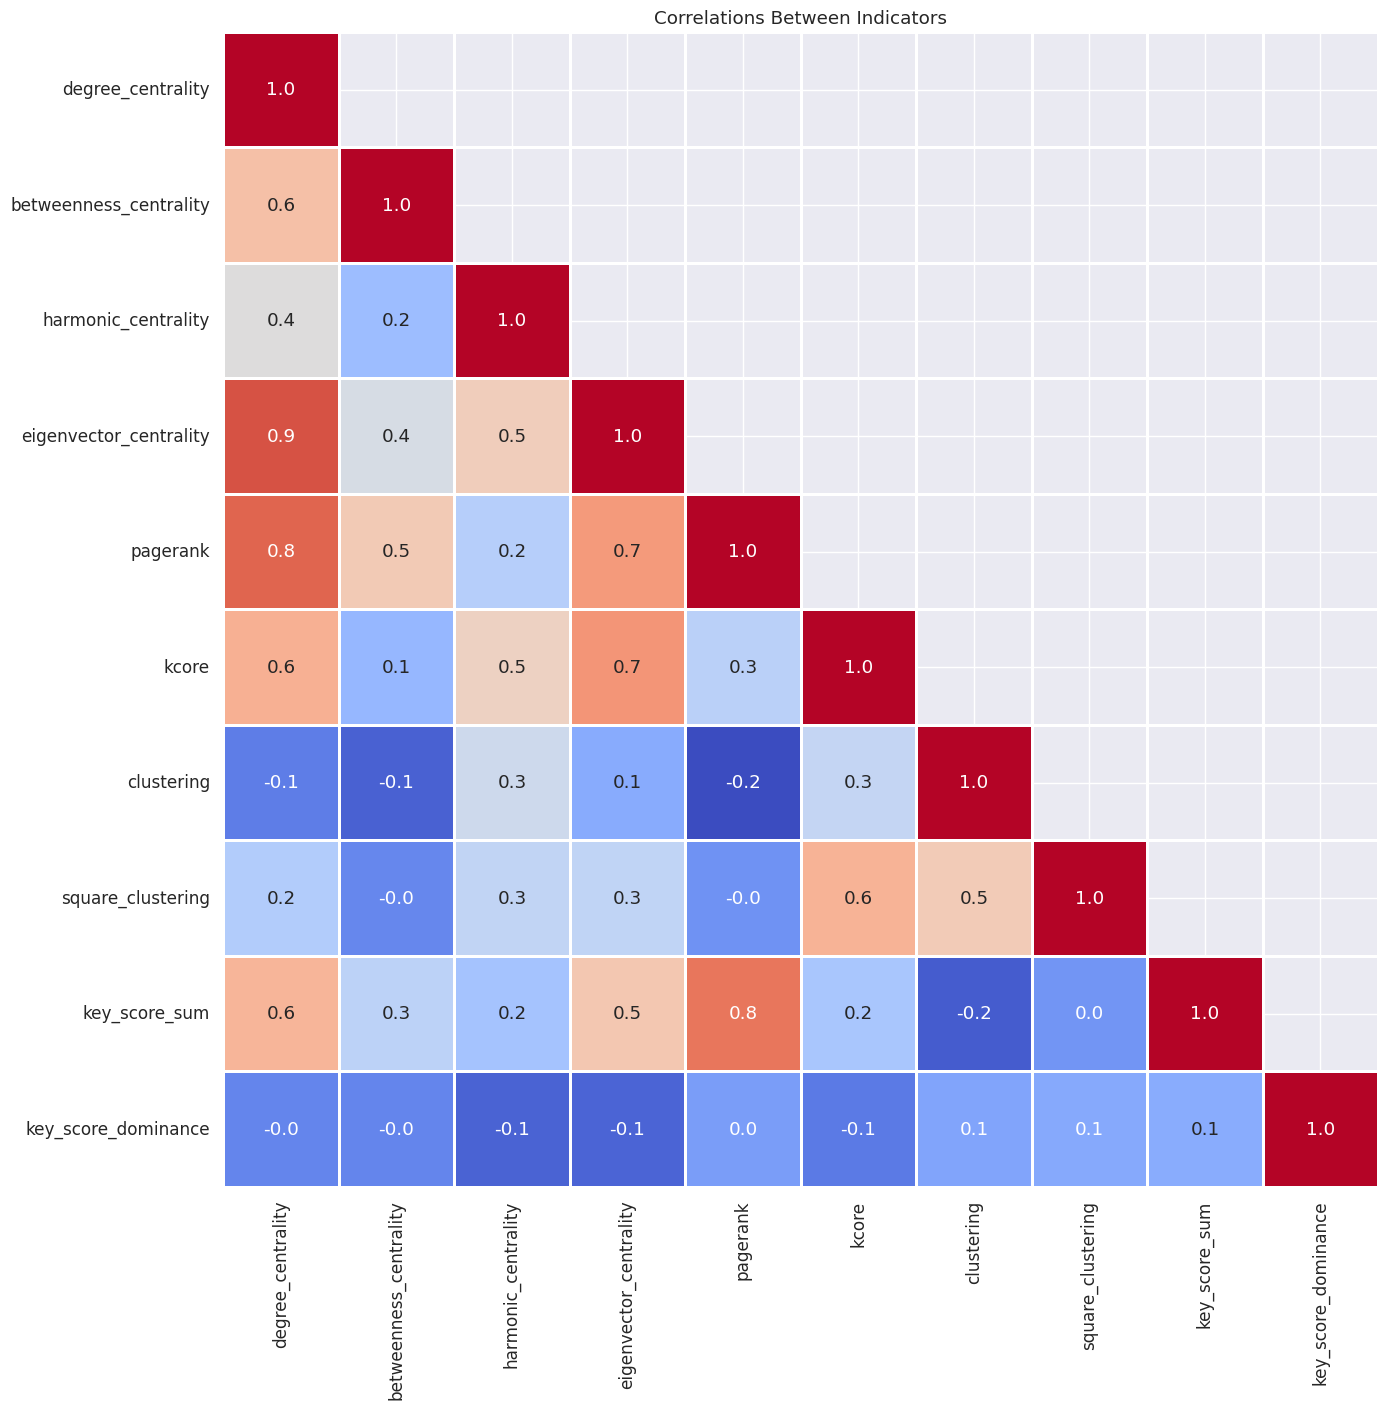

In [36]:
# Display correlations between indicators.
corr = node_indicators_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.set(font_scale=1.1)
plt.figure(figsize=(15, 15))
sns.heatmap(corr,
            annot=True,
            fmt='.1f',
            cmap='coolwarm',
            square=True,
            mask = mask,
            linewidths=1,
            cbar=False)
plt.title("Correlations Between Indicators")


plt.savefig(folder_output_path / "indicators_correlation_heatmap.png", dpi=300, bbox_inches="tight")
print(f"Saved indicators correlation heatmap to: {folder_output_path / 'indicators_correlation_heatmap.png'}")

plt.show()
plt.close()

## Z-Score

In [37]:
def zscore_from_series(values_series: pd.Series, ddof: int = 0) -> pd.Series:
    """Compute z-score normalization for a pandas Series.
    Args:
        s: Input series.
        ddof: Delta degrees of freedom for std (0=population, 1=sample).
    Returns:
        Z-scored series (same index).
    """
    mean = values_series.mean()
    std = values_series.std(ddof=ddof)

    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=values_series.index, name=f"{values_series.name}_z_score")

    return ((values_series - mean) / std).rename(f"{values_series.name}_z_score")


In [38]:
def compute_zscore(node_indicators_df : pd.DataFrame) -> pd.DataFrame:
    """Compute z-score normalization for all columns in a DataFrame.

    Args:
        node_indicators_df: Input DataFrame with numeric columns.

    Returns:
        zscore_df: DataFrame with z-scored columns.
    """
    
    zscore_df = pd.DataFrame()

    for col in node_indicators_df.columns:
        zscore_df[f"{col}"] = zscore_from_series(node_indicators_df[col])

    zscore_df.index = node_indicators_df.index

    zscore_df.index.name = "accountid"

    return zscore_df

In [39]:
node_indicators_zscore_df = compute_zscore(node_indicators_df)
print("#### zscore ####")
node_indicators_zscore_df.head()

#### zscore ####


,degree_centrality,betweenness_centrality,harmonic_centrality,eigenvector_centrality,pagerank,kcore,clustering,square_clustering,key_score_sum,key_score_dominance
accountid,,,,,,,,,,
bef0e7981715abed0539a1eb8eedfdbf59651779f2,1.881291,0.263002,0.675502,-0.130443,-0.010813,1.310726,-1.689842,-0.501384,-0.096316,-0.935701
9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,13.806306,16.630096,2.915071,9.374166,23.711568,1.904029,-2.140215,-0.499772,16.484947,0.273808
71b45b9cfbe033acf94c15763207cc9f35746ad22a,12.820420,7.229948,2.704423,9.225874,16.944312,1.904029,-2.115493,-0.443111,13.166970,0.361483
70977662b5d96b2cf7604f9de940a581576abcd991,14.522995,14.806341,2.908615,9.342736,17.957719,1.904029,-2.161669,-0.499235,10.519681,0.311513
cd0b8e047f5b20eed79cf903fd915afdf4458bc3b4,13.624511,10.493434,2.776722,8.663605,14.620151,1.904029,-2.144915,-0.488368,8.870552,0.391976


## Account Indicators Summery

In [40]:
def show_account_indicators(
    accountid,
    node_indicators_df: pd.DataFrame,
    node_indicators_zscore_df: pd.DataFrame,
) -> None:
    """Display raw indicators and z-scores for a single account.
    Args:
        accountid: Account identifier (must exist in both DataFrames).
        node_indicators_df: Raw node-level indicators indexed by accountid.
        node_indicators_zscore_df: Z-score–normalized indicators indexed by accountid.
    Returns:
        None
    Raises:
        KeyError: If accountid is not found in either DataFrame.
    """
    # Validate inputs
    if accountid not in node_indicators_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_df")
    if accountid not in node_indicators_zscore_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_zscore_df")


    # Extract rows
    raw_row = node_indicators_df.loc[accountid]
    z_row = node_indicators_zscore_df.loc[accountid]

    # Build records DataFrame
    records = [
        {
            "indicator": indicator,
            "value": raw_row[indicator],
            "z_score": z_row[indicator],
        }
        for indicator in node_indicators_df.columns
    ]
    records_df = pd.DataFrame(records)

    # Style for visual inspection
    styled = (
        records_df.style
        .background_gradient(subset=["z_score"], cmap="coolwarm", vmin=-1.5, vmax=1.5)
        .format({"value": "{:.3f}", "z_score": "{:.2f}"})
    )

    # Display
    print(f"Account ID: {accountid}")
    display(styled)

    return None

In [41]:
suspect_accountid = node_indicators_df.sample(n=1).iloc[0].name


show_account_indicators(
    accountid = suspect_accountid,
    node_indicators_df = node_indicators_df,
    node_indicators_zscore_df = node_indicators_zscore_df,
)

Account ID: c5cf4e6b01ce30e31d071c51b8582d5d6d83699ab0


,indicator,value,z_score
0,degree_centrality,0.009,-0.29
1,betweenness_centrality,0.000,-0.10
2,harmonic_centrality,2028.943,-0.12
3,eigenvector_centrality,0.003,-0.32
4,pagerank,0.000,0.14
5,kcore,50.000,-0.32
6,clustering,0.485,-0.29
7,square_clustering,0.201,0.08
8,key_score_sum,3.126,-0.18
9,key_score_dominance,0.233,-2.58


## Information Gain

In [42]:
def compute_indicators_information_gain(
    node_indicators_df: pd.DataFrame,
    io_authors: set,
    folder_path: str | Path | None = None,
    all_authors: Iterable[str] | None = None,
) -> pd.Series:
    """Compute information gain (mutual information) between centrality features
    and an IO-author label.

    Args:
        node_indicators_df: DataFrame with authors as index and
            centrality metrics as columns.
        io_authors: Set of author IDs labeled as IO (1). Others are control (0).
        folder_path: Optional path to save the information gain results.
        all_authors: Optional iterable of all author IDs. If provided, missing authors
            are added to node_indicators_df with zero-valued indicators, ensuring
            information gain is computed over the complete author population.

    Returns:
        pd.Series: Information gain per centrality feature, sorted descending.
    """
    # Ensure consistent typing
    io_authors = set(map(str, io_authors))
    
    # If all_authors provided, add missing authors with zero indicators
    if all_authors is not None:
        all_authors_set = set(map(str, all_authors))
        existing_authors = set(node_indicators_df.index.astype(str))
        missing_authors = all_authors_set - existing_authors
        
        if missing_authors:
            # Create zero-filled rows for missing authors
            zero_df = pd.DataFrame(
                0.0,
                index=list(missing_authors),
                columns=node_indicators_df.columns
            )
            zero_df.index.name = node_indicators_df.index.name
            node_indicators_df = pd.concat([node_indicators_df, zero_df], axis=0)
            print(f"Added {len(missing_authors)} missing authors with indicators values set to zero.")
    
    authors = node_indicators_df.index.astype(str)

    # Build binary label per author
    author_io_tag = authors.isin(io_authors).astype(int)

    # Prepare arrays for sklearn
    X = node_indicators_df.to_numpy()
    y = author_io_tag

    # Compute information gain (MI)
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    # Convert to Series and sort
    mi_series = pd.Series(
        mi,
        index=node_indicators_df.columns,
        name="information_gain"
    ).sort_values(ascending=False)

    # Save results
    if folder_path is not None:
        folder_path = Path(folder_path)
        info_gain_output_path = folder_path / "indicators_information_gain.parquet"
        mi_series.to_frame().to_parquet(info_gain_output_path, compression = "gzip")
        print(f"Saved information gain results to: {info_gain_output_path}")

    return mi_series

In [43]:
mi_series = compute_indicators_information_gain(
    node_indicators_df,
    io_authors_set,
    folder_output_path,
    all_authors=df[account_id_col].astype(str).unique(),
)
display(mi_series)

Added 15973 missing authors with indicators values set to zero.
Saved information gain results to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_information_gain.parquet


kcore                     0.086689
degree_centrality         0.076079
eigenvector_centrality    0.069288
harmonic_centrality       0.049765
square_clustering         0.045872
key_score_sum             0.042615
betweenness_centrality    0.040531
clustering                0.038271
key_score_dominance       0.037223
pagerank                  0.037068
Name: information_gain, dtype: float64

## Plot

### Indicators Information Gain

In [44]:
def plot_indicators_information_gain(
    mi_series: pd.Series,
    output_path: Path | str | None = None,
    filename: str = "indicators_information_gain.png",
    title: str = "Information Gain of Node Indicators for IO Driver Status",
) -> None:
    """Plot and save information gain per centrality feature.

    Args:
        mi_series: Information gain per centrality feature.
        output_path: Directory where the image will be saved.
        filename: Name of the output image file.
        title: Title of the plot.
    """

    # Create the plot
    plt.figure(figsize=(8, 4))
    mi_series.plot(kind="bar")

    plt.ylabel("Information gain")
    plt.xlabel("Indicators")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # Save figure
    if output_path is not None:
      output_path = Path(output_path)
      file_path = output_path / filename
      plt.savefig(file_path, dpi=300)
      print(f"Saved fig to: {file_path}")

    # Show figure
    plt.show()

    # Close figure
    plt.close()

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_information_gain_BERTopic_topic_512.png


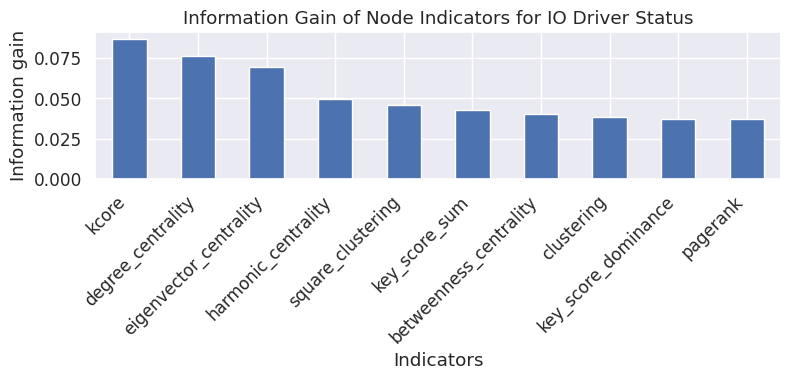

In [45]:
plot_indicators_information_gain(mi_series, folder_output_path, filename=f"indicators_information_gain_{topic_col}.png")

Added 15973 missing authors with indicators values set to zero.
Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_z_score_information_gain_BERTopic_topic_512.png


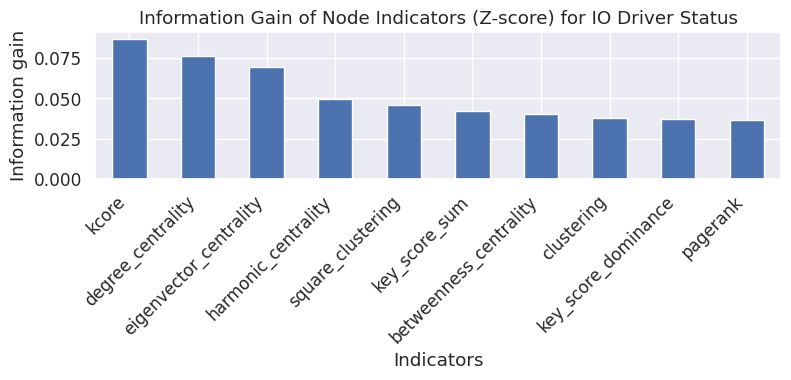

In [46]:
z_score_mi_series = compute_indicators_information_gain(
    node_indicators_zscore_df,
    io_authors_set,
    all_authors=df[account_id_col].astype(str).unique(),
)
plot_indicators_information_gain(z_score_mi_series, folder_output_path, filename=f"indicators_z_score_information_gain_{topic_col}.png", title = "Information Gain of Node Indicators (Z-score) for IO Driver Status")

### Distributions

In [47]:
def plot_indicators_distributions(
    node_indicators_df,
    output_path: str | Path | None = None,
    bins: int = 30,
):
    """Plot distributions of indicators for all authors.

    Args:
        node_indicators_df: DataFrame (index=author, columns=centralities).
        output_path: If given, save figure to this folder path.
        bins: Number of histogram bins.
    """
    features = node_indicators_df.columns
    n = len(features)

    rows = 2
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()  # key fix

    for ax, feature in zip(axes, features):
        ax.hist(node_indicators_df[feature], bins=bins, alpha=0.8)
        ax.set_title(feature)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")


    # remove unused axes (when n is odd)
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "indicators_distributions.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved indicators distributions to: {distributions_output_path}")

    plt.show()
    plt.close(fig)

Saved indicators distributions to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_distributions.png


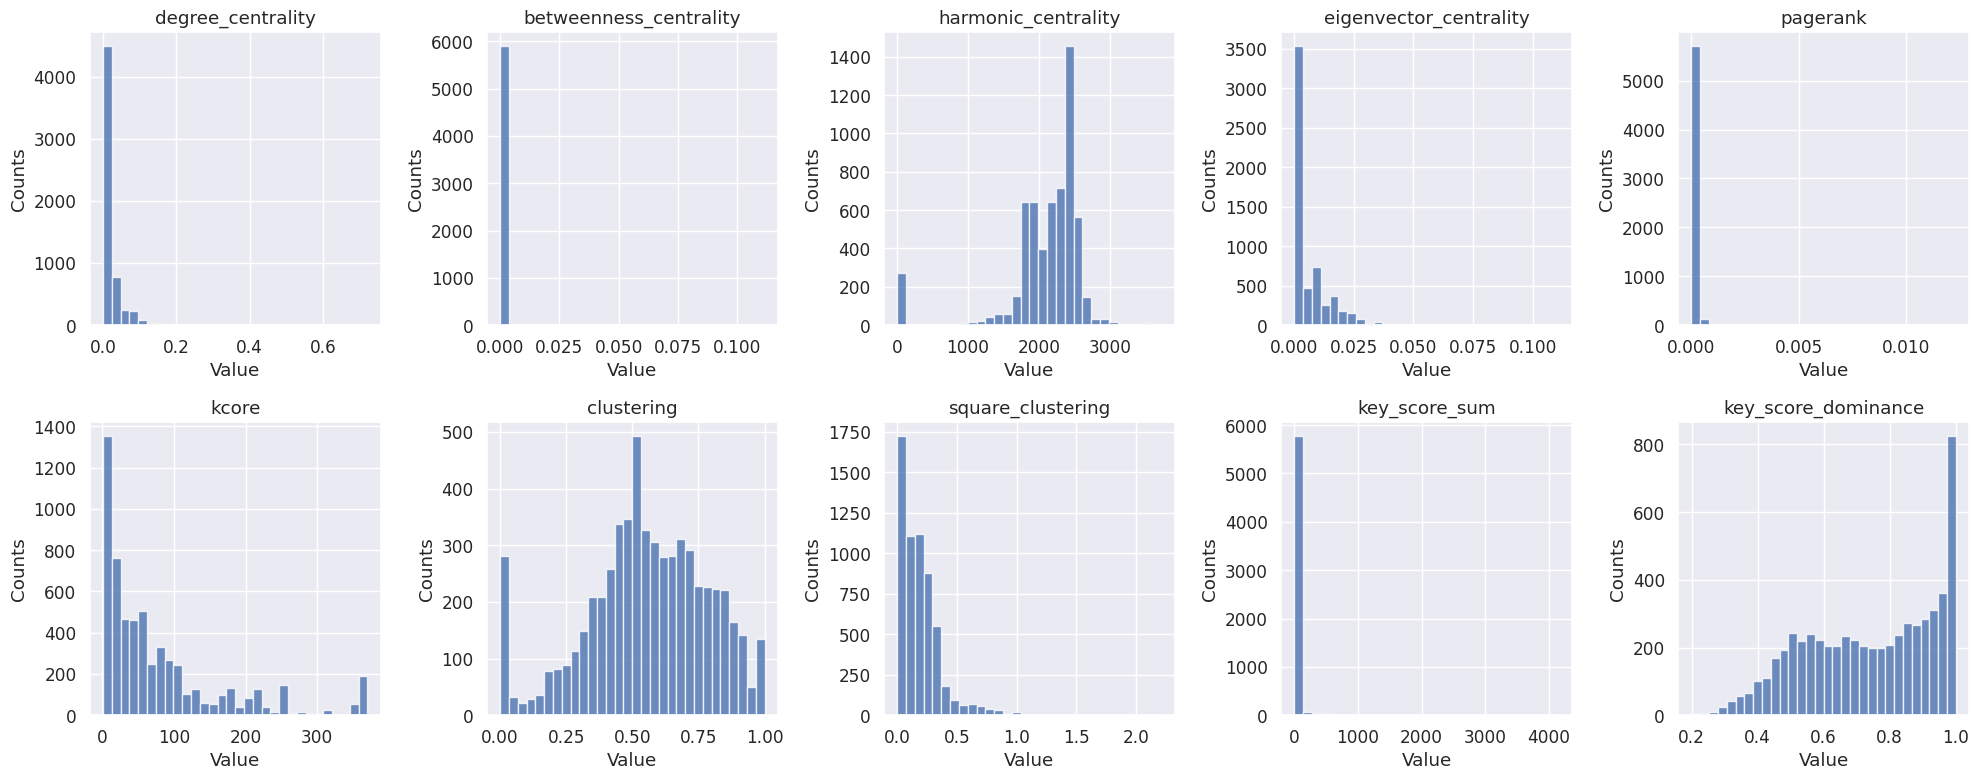

In [48]:
plot_indicators_distributions(node_indicators_df, folder_output_path)

### Boxplots

In [49]:
def plot_indicator_boxplots(node_indicators_df: pd.DataFrame, io_authors: set, output_folder_path: str | Path= None) -> None:
    """Create box plots of each indicator grouped by IO status.

    Args:
        node_indicators_df: DataFrame indexed by author/accountid with indicator columns.
        io_authors: Set of IO author IDs.
        output_folder_path: Optional path to save the plot image.
    """
    io_authors_set = set(map(str, io_authors))
    # idx_str = node_indicators_df.index.astype(str)

    plot_df = node_indicators_df.copy()

    io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)
    plot_df["io_status"] = np.where(io_mask, "IO", "Non-IO")

    # Keep only numeric indicators
    indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

    if not indicators:
        print("No numeric indicators found to plot.")
        return

    n = len(indicators)
    rows = 3 if n > 1 else 1
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = [axes] if not isinstance(axes, (list, tuple, pd.core.generic.NDFrame)) and getattr(axes, "plot", None) else axes
    axes = getattr(axes, "flatten", lambda: axes)()

    for ax, ind in zip(axes, indicators):
        plot_df.boxplot(column=ind, by="io_status", ax=ax, grid=False)
        ax.set_title(ind)
        ax.set_xlabel("IO status")
        ax.set_ylabel(ind)

    # Remove unused axes
    for ax in axes[n:]:
        ax.remove()

    # Remove pandas' automatic "Boxplot grouped by io_status"
    fig.suptitle("Indicators vs IO status")
    plt.title("")  # clears the auto-title added by pandas
    plt.tight_layout(rect=[0, 0, 1, 0.95])


    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        distributions_output_path = output_folder_path / "indicators_boxplots.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {distributions_output_path}")
    
    plt.show()
    plt.close()

Saved fig to: ../experimental_results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_boxplots.png


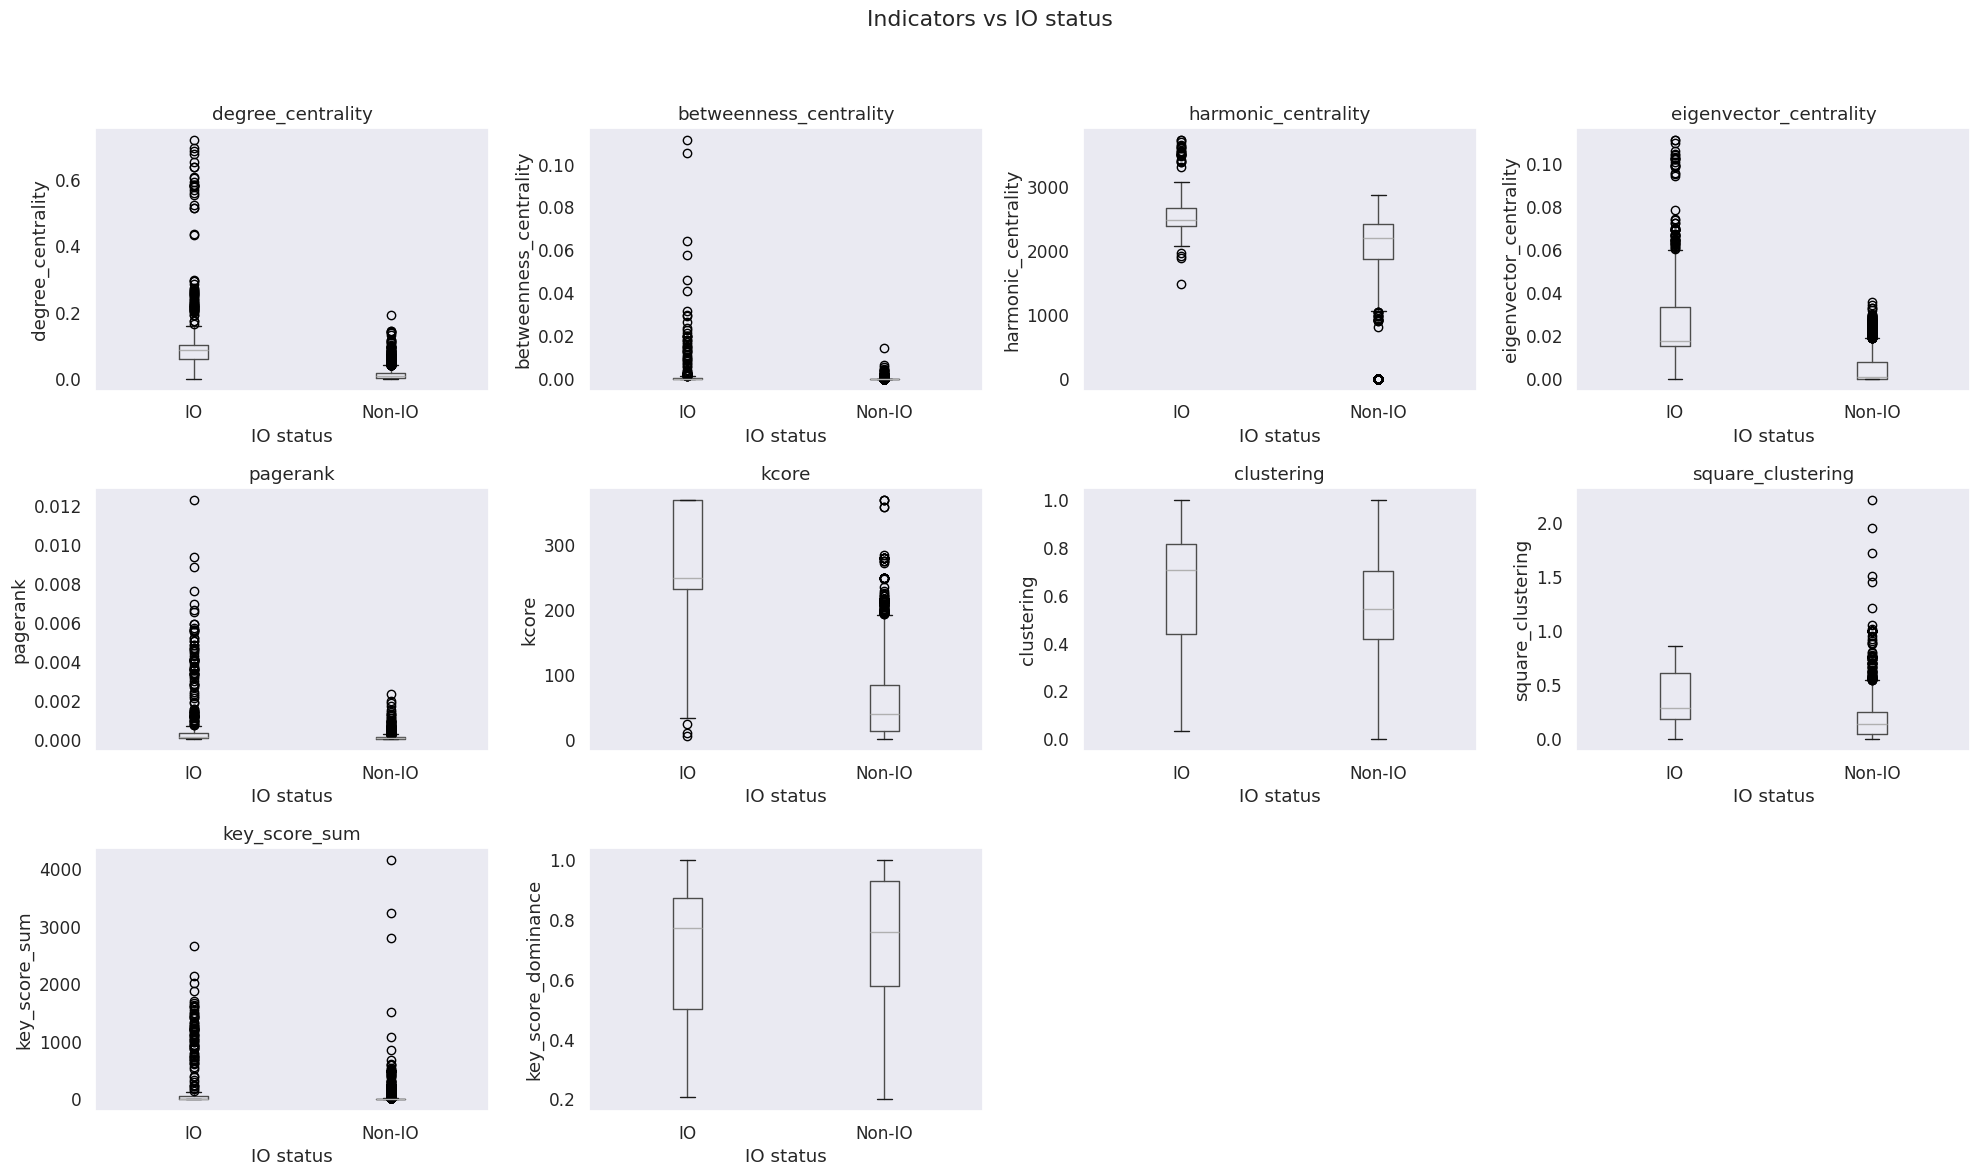

In [50]:
plot_indicator_boxplots(node_indicators_df, io_authors_set, output_folder_path = folder_output_path)

# Linear Coefficients

In [51]:
import pandas as pd
from pandas.api.types import is_numeric_dtype

io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)

# make it a Series with the same index
io_binary = pd.Series(io_mask.astype(int), index=node_indicators_df.index, name="io_binary")

indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

coefficients = {}
for indicator in indicators:
    coefficients[indicator] = node_indicators_df[indicator].corr(io_binary)  # Pearson by default

coefficients_df = (
    pd.Series(coefficients, name="correlation")
      .sort_values(ascending=False)
      .to_frame()
)

display(coefficients_df)


,correlation
kcore,0.726786
eigenvector_centrality,0.604159
degree_centrality,0.600069
square_clustering,0.379641
pagerank,0.354517
key_score_sum,0.277051
harmonic_centrality,0.261367
betweenness_centrality,0.204412
clustering,0.088305
key_score_dominance,-0.079069


In [ ]:
import matplotlib.pyplot as plt

def plot_io_correlations(
        coefficients_df,
        title="Indicator Linear Coefficients with IO Label",
        folder_output_path: str | Path | None = None,
    ) -> None:
    """Plot correlation of graph indicators with IO binary label.

    Args:
        coefficients_df: DataFrame with index=indicator, column 'correlation'.
        title: Plot title.
    """
    df = coefficients_df.sort_values("correlation")

    plt.figure(figsize=(8, max(4, 0.35 * len(df))))
    plt.barh(df.index, df["correlation"])
    plt.axvline(0)
    plt.xlabel("Correlation with IO (binary)")
    plt.title(title)
    plt.tight_layout()
    if folder_output_path is not None:
        plt.savefig(folder_output_path / "indicators_io_linear_coefficients.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

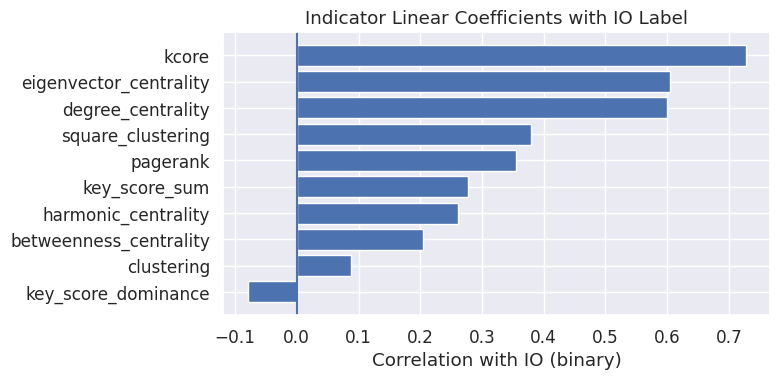

In [ ]:
plot_io_correlations(coefficients_df, folder_output_path = folder_output_path)

# Exit

In [54]:
# For Testing: exit here to avoid running the rest of the notebook
# import sys
# sys.exit(0)

# Parameter Sweep: Information Gain Analysis

This section implements functions to run key_authors_graph with different min_topic_size and top_n values, compute total information gain, and visualize results.

In [ ]:
from itertools import product
from typing import Iterable, Sequence

## One Experiment

In [ ]:
def run_io_indicator_ig_experiment(
    df: pd.DataFrame,
    min_topic_size: int,
    top_percentage: float,
    account_relations: Iterable[tuple[str, str]],
    is_directed_graphs: bool,
    base_topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    key_authors_mode: str = "per_topic",
    entity_cols_lst: list[str] = ["hashtags", "account_mentions", "urls", "ner_entities"],
) -> pd.DataFrame:
    """Run a full IO experiment pipeline and return summary metrics.

    Pipeline:
      1) topic_col = f"{base_topic_col}_{min_topic_size}"
      2) get_io_authors_by_ratio(...) -> io_authors
      3) get_all_topics_key_authors(...) -> all_topics_key_authors_df
      4) build_accounts_graph(...) -> G
      5) compute_indicators(G) -> node_indicators_df
      6) compute_centrality_information_gain(...) -> IG per indicator
      7) return sum + mean IG.

    Returns:
        Single-row DataFrame with min_topic_size, top_n, is_directed_graphs,
        ig_sum, ig_mean (+ helpful counts).
    """
    # ---------- 0) topic_col ----------
    topic_col = f"{base_topic_col}_{min_topic_size}"
    if topic_col not in df.columns:
        raise KeyError(f"[MY ERROR] topic_col '{topic_col}' not found in df.columns")

    # ---------- 1) IO authors ----------
    io_authors = get_io_authors_by_ratio(
        df=df,
        author_col=author_col,
        is_io_control_col=is_io_control_col,
        io_threshold=io_threshold,
        min_posts=min_posts,
    )
    io_authors_set = set(map(str, io_authors))

    # ---------- 2) key authors ----------

    post_score_col = f"post_tfidf_{topic_col}"
    author_score_col = f"topic_author_key_score_{topic_col}"


    compute_post_tfidf(df, topic_col, entity_cols_lst, post_score_col)
    
    
    # author_topic_key_score_df (rows = authors, columns = topics, values = author-topic score)
    author_topic_key_score_df = compute_author_key_score( 
        df=df,
        topic_col=topic_col,
        author_col=author_col,
        post_score_col = post_score_col,
        author_score_col = author_score_col,
    )
    
    all_topics_key_authors_df, all_topics_key_authors_set = get_all_topics_key_authors(
        df=df,
        author_score_col=author_score_col,
        author_col=author_col,
        topic_col=topic_col,
        key_authors_mode = key_authors_mode,
        base_number= 10,
        top_percentage = top_percentage,
    )

    # ---------- 3) build graph ----------
    G = build_accounts_graph(
        df=df,
        account_relations=account_relations,
        io_authors=io_authors,
        all_topics_key_authors_set = all_topics_key_authors_set,
        author_topic_key_score_df = author_topic_key_score_df, # for node labels.
        is_directed_graphs=is_directed_graphs,
        topic_col=topic_col,
    )

    # ---------- 4) compute indicators ----------
    node_indicators_df = compute_indicators(G)

    # ---------- 5) IG ----------
    ig_series = compute_indicators_information_gain(
        node_indicators_df,
        io_authors_set,
        all_authors=df[author_col].astype(str).unique(),
    )
    ig_series = pd.to_numeric(ig_series, errors="coerce").dropna()

    ig_sum = float(ig_series.sum())
    ig_mean = float(ig_series.mean())

    # ---------- output ----------
    return pd.DataFrame([{
        "model": base_topic_col,
        "min_topic_size": int(min_topic_size),
        "top_percentage": float(top_percentage),
        "is_directed_graphs": bool(is_directed_graphs),
        "ig_sum": ig_sum,
        "ig_mean": ig_mean,
        "n_indicators": int(len(ig_series)),
        "n_nodes": int(node_indicators_df.shape[0]),
        "n_io_authors": int(len(io_authors_set)),
        "n_account_relations": int(len(account_relations)),
    }])

## Grid Experiments

In [57]:
key_authors_mode = "per_topic"  # "per_topic" or "global"

In [ ]:
def run_io_indicator_ig_grid(
    df: pd.DataFrame,
    min_topic_size_lst: Sequence[int],
    top_percentage_lst: Sequence[int],
    account_relations: Iterable[tuple[str, str]], # this is one configurations of account_relations.
    is_directed_graphs_lst: Sequence[bool] = (False, True),
    base_topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    output_folder_path: str | Path | None = None,
    key_authors_mode: str = "per_topic",
    entity_cols_lst: list[str] = ["hashtags", "account_mentions", "urls", "ner_entities"]
) -> pd.DataFrame:
    """Run run_io_indicator_ig_experiment over a grid of configurations.

    Args:
        df: Posts DataFrame.
        min_topic_size_lst: List of min_topic_size values to test.
        top_percentage_lst: List of top_percentage values to test. top_percentage: Top percentage of authors per topic.
        account_relations: Relations used by build_accounts_graph.
        is_directed_graphs_lst: Which directed settings to test.
        base_topic_col, author_col, score_col, is_io_control_col, io_threshold, min_posts:
            Passed through to run_io_indicator_ig_experiment.
        output_folder_path: Optional path to save output files.
        key_authors_mode: If choose key authors globally of per topic. 
        entity_cols_lst: a list of entities types to consider.
        

    Returns:
        Merged DataFrame of all runs, with a num_of_configuration column (1..N).
    """
    grid_results: list[pd.DataFrame] = []

    for cfg_idx, (min_topic_size, top_percentage, is_directed) in enumerate(
        product(min_topic_size_lst, top_percentage_lst, is_directed_graphs_lst), # all possible combinations
        start=1,
    ):
        results = run_io_indicator_ig_experiment(
            df=df,
            min_topic_size=int(min_topic_size),
            top_percentage=float(top_percentage),
            account_relations=account_relations,
            is_directed_graphs=bool(is_directed),
            base_topic_col=base_topic_col,
            author_col=author_col,
            is_io_control_col=is_io_control_col,
            io_threshold=io_threshold,
            min_posts=min_posts,
            key_authors_mode = key_authors_mode,
            entity_cols_lst =  entity_cols_lst,
        )
        results["configuration_number"] = cfg_idx
        grid_results.append(results)


    out = pd.concat(grid_results, ignore_index=True) # merge

    # Ordering
    sort_cols = [c for c in ["min_topic_size", "top_percentage", "is_directed_graphs"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    # Save
    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        grid_output_path = output_folder_path / f"io_indicator_ig_experiment_grid_results.parquet"
        out.to_parquet(grid_output_path, index=False, compression="gzip")
        print(f"Saved grid results to: {grid_output_path}")
    else:
        print("No output_folder_path provided, skipping saving grid results.")

    return out

: 

In [ ]:
# %%capture

grid_df = run_io_indicator_ig_grid(
    df=df,
    min_topic_size_lst=[128, 256, 512],
    top_percentage_lst=[0.05, 0.1, 0.2],
    account_relations=account_relations,
    is_directed_graphs_lst=[False, True],
    output_folder_path=folder_output_path,
    key_authors_mode = key_authors_mode, # "per_topic" or "global"
    entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"],
)

There are 711 io authors.
Using topic column: BERTopic_topic_128
Using entity columns: ['hashtags', 'account_mentions', 'urls', 'ner_entities']

Using topic column: BERTopic_topic_128


Add tf-idf scores of hashtags: 100%|██████████| 1468565/1468565 [00:02<00:00, 730126.10it/s]


Using topic column: BERTopic_topic_128


Add tf-idf scores of account_mentions: 100%|██████████| 1468565/1468565 [00:04<00:00, 364212.07it/s]


Using topic column: BERTopic_topic_128


In [ ]:
display(grid_df)

## Plot

In [ ]:
def plot_ig_grid_results(
    grid_df: pd.DataFrame,
    y_col: str = "ig_sum",
    output_path: str | Path | None = None,
) -> None:
    """Plot information gain metrics vs top_n parameter from grid search results.

    Creates a line plot with:
    - Separate lines for directed and undirected graphs (color + marker)
    - Separate line styles for different min_topic_size values (solid/dashed)

    Args:
        grid_df: DataFrame from run_io_indicator_ig_grid with columns:
            top_n, is_directed_graphs, min_topic_size, ig_sum, ig_mean, etc.
        y_col: Column name to plot on y-axis (e.g., 'ig_sum' or 'ig_mean').
        output_path: Directory to save the plot.
    """
    if grid_df.empty:
        print("Warning: grid_df is empty, cannot plot.")
        return

    if y_col not in grid_df.columns:
        raise ValueError(f"Column '{y_col}' not found in grid_df. Available: {grid_df.columns.tolist()}")
    

    # title and y-label
    y_label_map = {
        "ig_sum": "Total Information Gain",
        "ig_mean": "Mean Information Gain",
        }
    y_label = y_label_map.get(y_col, y_col)
    title = f"{y_label} vs top_percentage Key Authors"

    # Create figure
    plt.figure(figsize=(12, 6))

    # Get unique min_topic_size values and assign colors
    min_topic_sizes = sorted(grid_df["min_topic_size"].unique())
    # Use distinct colors for different min_topic_size values
    available_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    colors_map = {
        min_topic_size: available_colors[i % len(available_colors)]
        for i, min_topic_size in enumerate(min_topic_sizes)
    }

    # Plot separate lines for each combination of (min_topic_size, is_directed)
    for min_topic_size in min_topic_sizes:
        for is_directed in sorted(grid_df["is_directed_graphs"].unique()):
            subset = grid_df[
                (grid_df["min_topic_size"] == min_topic_size) & 
                (grid_df["is_directed_graphs"] == is_directed)
            ].sort_values("top_percentage")
            
            if subset.empty:
                continue
            
            # Build label
            graph_type = "Directed" if is_directed else "Undirected"
            label = f"{graph_type} (min_topic_size={min_topic_size})"
            
            # Colors based on min_topic_size, line style based on directed/undirected
            marker = "s" if is_directed else "o"  # square for directed, circle for undirected
            color = colors_map[min_topic_size]  # color based on min_topic_size
            linestyle = "solid" if is_directed else "dashed"  # solid for directed, dashed for undirected
            
            plt.plot(
                subset["top_percentage"],
                subset[y_col],
                marker=marker,
                markersize=8,
                linewidth=2,
                linestyle=linestyle,
                label=label,
                color=color,
                alpha=0.8,
            )

    # Styling
    plt.xlabel("Percentage of Top Authors per Topic (top_percentage)", fontsize=12)
    
    plt.ylabel(y_label_map.get(y_col, y_col), fontsize=12)
    
    plt.title(title, fontsize=14, fontweight="bold")
    plt.legend(loc="best", frameon=True, fontsize=10)
    plt.grid(axis="both", alpha=0.3)
    
    # Set x-axis to show all top_percentage values
    top_percentage_values = sorted(grid_df["top_percentage"].unique())
    plt.xticks(top_percentage_values)
    
    plt.tight_layout()

    # Save
    if output_path is not None:
        output_path = Path(output_path)
        filename = f"{y_col}_vs_top_percentage.png"
        file_path = output_path / filename
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {file_path}")

    plt.show()
    plt.close()

In [ ]:
# Plot ig_mean vs top_n (optional)
plot_ig_grid_results(
    grid_df=grid_df,
    y_col="ig_sum",
    output_path=folder_output_path,
)